# §2.1 Select states of the world

This notebook covers how the joint distribution of EV adoption rates is constructed from adoption forecasts proposed by Ledna et al. (2024). The fitted parameters from this notebook are plugged into LAUREL's configuration files as a part of creating the 1,024 SoWs we investigated.

**Generates:** appendix Figure A.11 (adoption correlation scatter matrix). The fitted beta marginals and Gaussian-copula correlation matrix are the parameters exported to the `sense_manage` scenario configuration.

## Load modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import openturns as ot
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from laurel.scenario_builders.sense import (
    SenseScenarioBuilder,
    SenseScenarioReader,
)
from laurel.utils.params import tabularize_params
from laurel.utils.sensitivity import correl_dict_to_matrix, correl_matrix_to_dict

## Set global variables

In [2]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

In [3]:
SCENARIO = 2035
SCENARIO_DELAY = 1
VEHICLE_CLASS = "Heavy (Classes 7-8)"

## Load data

In [23]:
%reload_ext kedro.ipython
%reload_kedro --env=scenario_builders/sense_manage --params=data_dir=/scratch/users/passow/laurel/data

[06/11/26 09:06:33] INFO     Registered line magic '%reload_kedro'                                   ]8;id=925736;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=987614;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=792799;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=724268;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=945589;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=819139;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:06:34] INFO     Kedro project LAUREL                                                   ]8;id=656352;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=95005;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=318451;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=802144;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=50731;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=536208;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=750372;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=78654;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:06:36] INFO     Kedro project LAUREL                                                   ]8;id=655448;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=309590;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=765687;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=294938;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=963842;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=343718;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [24]:
adopts = catalog.load("ledna_adoption")

[06/11/26 09:06:37] INFO     Loading data from ledna_adoption (ExcelDataset)...                ]8;id=929206;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=64416;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [25]:
adopt_mapper = catalog.load("params:adoption_forecast_classifications")

[06/11/26 09:06:39] INFO     Loading data from params:adoption_forecast_classifications        ]8;id=618912;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=845501;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (MemoryDataset)...                                                                    

## Filter down to relevant adoption rates

We want just adoption rates for heavy vehicles in the selected years.

In [26]:
is_heavy = adopts["Vehicle Class"] == VEHICLE_CLASS
adopts["fuel_type"] = adopts["Technology"].map(adopt_mapper["fuel_type"]["values"])
adopts["primary_op_dist"] = adopts["Market Segment"].map(adopt_mapper["primary_op_dist"]["values"])
adopts["n_veh_stock"] = adopts["Vehicle Stock"] * 1e6
adopts_heavy = adopts.loc[is_heavy, :]

In [27]:
group_cols = ["Year", "primary_op_dist", "Scenario"]
n_veh_stock_all_fuels = adopts_heavy.groupby(group_cols)["n_veh_stock"].sum()
n_veh_stock_all_fuels.name = "n_veh_stock_all_fuels"

In [28]:
is_electric = adopts_heavy["fuel_type"] == "electricity"
adopt_elect = adopts_heavy.loc[is_electric]
adopt_elect = adopt_elect.groupby(group_cols)["n_veh_stock"].sum().to_frame()

adopt_elect = adopt_elect.join(n_veh_stock_all_fuels)
adopt_elect["adopt_frac"] = adopt_elect["n_veh_stock"] / adopt_elect["n_veh_stock_all_fuels"]

In [29]:
adopt_corr = adopt_elect["adopt_frac"].unstack(["primary_op_dist"], fill_value=0.0)
adopt_corr

primary_op_dist                  0-99 Miles  100-249 Miles  250-499 Miles  \
Year Scenario                                                               
2023 Adv. Electricity Price        0.000000       0.000000       0.000000   
     Adv. Hydrogen Price           0.000000       0.000000       0.000000   
     Adv. ICEV & HEV Technology    0.000000       0.000000       0.000000   
     Central                       0.000000       0.000000       0.000000   
     Central - with IRA            0.000000       0.000000       0.000000   
...                                     ...            ...            ...   
2050 Cons. Hydrogen Price          0.649102       0.632734       0.522450   
     Cons. ZEV Technology          0.111570       0.081530       0.035382   
     High Diesel                   0.664574       0.593750       0.410840   
     Low Diesel                    0.567449       0.193234       0.093938   
     No EV-150                     0.216565       0.416616       0.288227   

primary_op_dist                  500+ Miles  
Year Scenario                                
2023 Adv. Electricity Price        0.000000  
     Adv. Hydrogen Price           0.000000  
     Adv. ICEV & HEV Technology    0.000000  
     Central                       0.000000  
     Central - with IRA            0.000000  
...                                     ...  
2050 Cons. Hydrogen Price          0.414282  
     Cons. ZEV Technology          0.002915  
     High Diesel                   0.194010  
     Low Diesel                    0.026898  
     No EV-150                     0.127916  

[336 rows x 4 columns]

In [30]:
idx = pd.IndexSlice
year_range = np.arange(start=SCENARIO - SCENARIO_DELAY, stop=SCENARIO) + 1
year_range_df = adopt_corr.loc[idx[year_range], :]

## Fit a copula model over adoption rates

A copula captures the correlation between adoption fractions across vehicle operating-distance classes. We fit **beta-distributed marginals** to each class's NLR adoption fractions (`ot.BetaFactory`, with the lower bound fixed at 0), transform the sample to uniform margins via those marginals' CDFs, and fit a **Gaussian copula** (`ot.NormalCopula`) to the resulting correlation matrix. The 1,024 SoWs are later drawn from this joint distribution with a quasi-random Sobol' sequence (see the manuscript's Methods).

In [31]:
corr_df = year_range_df.copy()
corr_df.columns = ["_".join(map(str, col)) if isinstance(col, tuple) else str(col) for col in corr_df.columns]

In [32]:
sample = ot.Sample.BuildFromDataFrame(corr_df)

In [33]:
factory = ot.BetaFactory()
factory.setKnownParameter([2], [0.0])
estimated_marginals = []
for i in range(sample.getDimension()):
    dist = factory.build(sample.getMarginal(i))
    dist.setName(sample.getDescription()[i])
    estimated_marginals.append(dist)
# estimated_marginals

In [34]:
copula_sample = ot.Sample(sample.getSize(), sample.getDimension())
copula_sample.setDescription(sample.getDescription())
for index in range(sample.getDimension()):
    copula_sample[:, index] = estimated_marginals[index].computeCDF(sample[:, index])

In [35]:
lin_cor = copula_sample.computeLinearCorrelation()

In [36]:
estimated_copula = ot.NormalCopula(copula_sample.computeLinearCorrelation())
estimated_copula.setDescription(copula_sample.getDescription())

In [37]:
estimated_distribution = ot.JointDistribution(estimated_marginals, estimated_copula)
estimated_distribution.setDescription(sample.getDescription())

In [38]:
estimated_distribution

Index,Variable,Distribution
0,0-99 Miles,"Beta(alpha = 0.62385, beta = 0.931733, a = 0, b = 0.286857)"
1,100-249 Miles,"Beta(alpha = 0.486616, beta = 0.956853, a = 0, b = 0.291189)"
2,250-499 Miles,"Beta(alpha = 0.541241, beta = 1.1166, a = 0, b = 0.203155)"
3,500+ Miles,"Beta(alpha = 0.318571, beta = 0.906682, a = 0, b = 0.118803)"


We then plug these values into the configuration for the `sense_manage` scenarios. In the next section, we generate the specific scenario set from these values and compare to the original values from Ledna et al. (2024).

## Build the adoption parameter sets for the evaluated SoWs

In [39]:
scen_params = catalog.load("params:scenario_params")
all_params = catalog.load("parameters")
base_catalog = catalog.load("base_catalog")

all_cfgs = SenseScenarioBuilder(scen_params=scen_params, all_params=all_params, catalog=base_catalog).build_configs()

[06/11/26 09:06:47] INFO     Loading data from params:scenario_params (MemoryDataset)...       ]8;id=856059;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=82217;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from parameters (MemoryDataset)...                   ]8;id=838011;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=95791;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from base_catalog (YAMLDataset)...                   ]8;id=883476;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=222039;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [40]:
params_only = [v for k, v in all_cfgs.items() if k.endswith("parameters")]
adopt_dict = {i: v["compute_adoption_totals"]["adoption_fracs"]["values"] for i, v in enumerate(params_only)}
adopt_df = pd.DataFrame.from_dict(adopt_dict, orient="index")

### Figure A.11: Adoption correlation scatter matrix

Generates **Figure A.11** in the appendix. Pair grid showing correlations between e-HDT adoption fractions across vehicle operating distance classes (short-haul through long-haul), comparing NLR baseline scenarios (lower triangle) with Sobol'-sampled SoWs (upper triangle). Verifies that the 1,024 sampled SoWs cover a plausible range of correlated adoption trajectories.

[06/11/26 09:06:50] INFO     Saving data to adoption_copula_figure (MatplotlibDataset)...      ]8;id=458701;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=610594;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

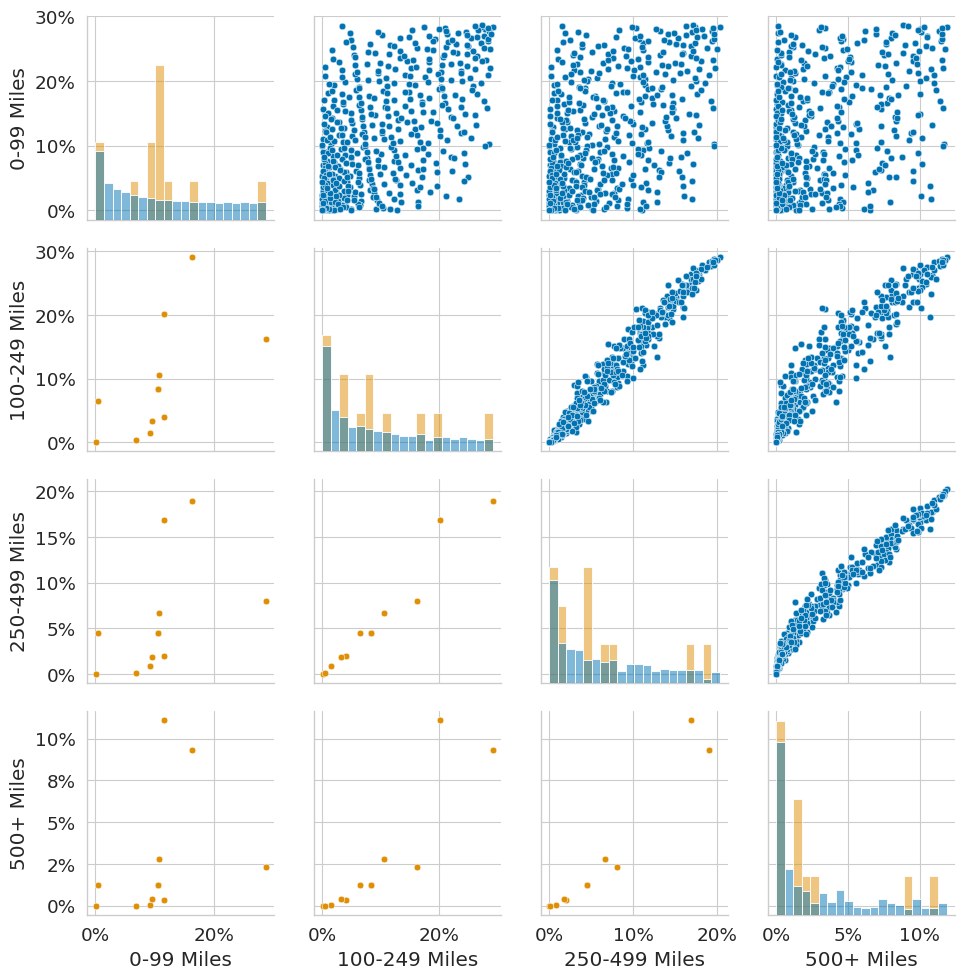

In [41]:
df_lower = year_range_df
df_upper = adopt_df

pair_levels = ["upper", "lower"]
pair_pal = sns.color_palette("colorblind", n_colors=2)

pair_pal_corresp = {lev: c for lev, c in zip(pair_levels, pair_pal)}

vars_ = df_upper.columns  # must match in both
p = sns.PairGrid(df_upper, vars=vars_)  # defines axes layout

def diag_pair_hist(x, **kws):
    data_upper = kws.pop("data_upper").reset_index(drop=True)
    data_lower = kws.pop('data_lower').reset_index(drop=True)
    data_combo = pd.concat(
        [data_upper, data_lower],
        keys=["upper", "lower"],
        names=["data_source"],
    )
    ax = plt.gca()
    sns.histplot(
        data=data_combo,
        x=x.name,
        hue="data_source",
        palette=pair_pal_corresp,
        common_norm=False,
        legend=False,
        ax=ax,
        **kws,
    )

def upper_scatter(x, y, **kws):
    data = kws.pop("data_other")
    ax = plt.gca()
    sns.scatterplot(data=data, x=x.name, y=y.name, ax=ax, **kws)

def lower_scatter(x, y, **kws):
    data = kws.pop("data_other")
    ax = plt.gca()
    sns.scatterplot(data=data, x=x.name, y=y.name, ax=ax, **kws)

p.map_diag(diag_pair_hist, data_upper=df_upper, data_lower=df_lower, stat="proportion", bins=20)  # uses df_upper; you can do similar wrappers for diag too
p.map_upper(upper_scatter, data_other=df_upper, color=pair_pal_corresp["upper"])
p.map_lower(lower_scatter, data_other=df_lower, color=pair_pal_corresp["lower"])

for axis in p.axes.flatten():
    if axis is None:
        continue
    axis.xaxis.set_major_formatter(PercentFormatter(1, decimals=0));
    axis.yaxis.set_major_formatter(PercentFormatter(1, decimals=0));

catalog.save("adoption_copula_figure", p.figure)
p.figure